In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("students_ai_usage (1).csv")
df.head()

,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours
0,19,college,1.4,No,NaN,NaN,62,62,3
1,15,school,3.9,Yes,Copilot,Research,56,61,2
2,15,school,1.9,Yes,Copilot,Homework,75,88,5
3,15,school,2.8,No,NaN,NaN,55,55,3
4,19,college,2.7,No,NaN,NaN,59,59,3


# **TASK 1: Data Collection & Dataset Understanding**

In [4]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(100, 9)


In [5]:
print("Columns:")
print(df.columns)

Columns:
Index(['age', 'education_level', 'study_hours_per_day', 'uses_ai',
       'ai_tools_used', 'purpose_of_ai', 'grades_before_ai', 'grades_after_ai',
       'daily_screen_time_hours'],
      dtype='object')


In [6]:
print("Data Types:")
print(df.dtypes)

Data Types:
age                          int64
education_level             object
study_hours_per_day        float64
uses_ai                     object
ai_tools_used               object
purpose_of_ai               object
grades_before_ai             int64
grades_after_ai              int64
daily_screen_time_hours      int64
dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      100 non-null    int64  
 1   education_level          100 non-null    object 
 2   study_hours_per_day      100 non-null    float64
 3   uses_ai                  100 non-null    object 
 4   ai_tools_used            40 non-null     object 
 5   purpose_of_ai            40 non-null     object 
 6   grades_before_ai         100 non-null    int64  
 7   grades_after_ai          100 non-null    int64  
 8   daily_screen_time_hours  100 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 7.2+ KB


In [8]:
df.describe()

,age,study_hours_per_day,grades_before_ai,grades_after_ai,daily_screen_time_hours
count,100.000000,100.000000,100.00000,100.000000,100.000000
mean,16.490000,2.987000,64.77000,68.700000,4.340000
std,1.702612,1.145713,6.16909,8.140806,1.793479
min,14.000000,1.000000,55.00000,55.000000,2.000000
25%,15.000000,1.975000,59.00000,61.000000,3.000000
50%,16.000000,2.800000,63.00000,69.000000,4.000000
75%,18.000000,4.025000,70.00000,74.000000,6.000000
max,19.000000,5.000000,75.00000,89.000000,7.000000


In [9]:
df.isnull().sum()

,0
age,0
education_level,0
study_hours_per_day,0
uses_ai,0
ai_tools_used,60
purpose_of_ai,60
grades_before_ai,0
grades_after_ai,0
daily_screen_time_hours,0


# **TASK 2: Data Cleaning & Preprocessing**

In [10]:
print(df.isnull().sum())

age                         0
education_level             0
study_hours_per_day         0
uses_ai                     0
ai_tools_used              60
purpose_of_ai              60
grades_before_ai            0
grades_after_ai             0
daily_screen_time_hours     0
dtype: int64


In [11]:
df['ai_tools_used'] = df['ai_tools_used'].fillna('Not Applicable')
df['purpose_of_ai'] = df['purpose_of_ai'].fillna('Not Applicable')

In [12]:
print(df.isnull().sum())

age                        0
education_level            0
study_hours_per_day        0
uses_ai                    0
ai_tools_used              0
purpose_of_ai              0
grades_before_ai           0
grades_after_ai            0
daily_screen_time_hours    0
dtype: int64


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
df = df.drop_duplicates()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      100 non-null    int64  
 1   education_level          100 non-null    object 
 2   study_hours_per_day      100 non-null    float64
 3   uses_ai                  100 non-null    object 
 4   ai_tools_used            100 non-null    object 
 5   purpose_of_ai            100 non-null    object 
 6   grades_before_ai         100 non-null    int64  
 7   grades_after_ai          100 non-null    int64  
 8   daily_screen_time_hours  100 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 7.2+ KB


# **TASK 3: Exploratory Data Analysis (EDA)**

In [16]:
df.describe()

,age,study_hours_per_day,grades_before_ai,grades_after_ai,daily_screen_time_hours
count,100.000000,100.000000,100.00000,100.000000,100.000000
mean,16.490000,2.987000,64.77000,68.700000,4.340000
std,1.702612,1.145713,6.16909,8.140806,1.793479
min,14.000000,1.000000,55.00000,55.000000,2.000000
25%,15.000000,1.975000,59.00000,61.000000,3.000000
50%,16.000000,2.800000,63.00000,69.000000,4.000000
75%,18.000000,4.025000,70.00000,74.000000,6.000000
max,19.000000,5.000000,75.00000,89.000000,7.000000


In [17]:
print("Average Grade Before AI:",
      df['grades_before_ai'].mean())
print("Average Grade After AI:",
      df['grades_after_ai'].mean())

Average Grade Before AI: 64.77
Average Grade After AI: 68.7


In [18]:
df['uses_ai'].value_counts()

,count
uses_ai,
No,60
Yes,40


In [19]:
df['education_level'].value_counts()

,count
education_level,
school,52
college,48


In [20]:
df['grade_improvement'] = (
    df['grades_after_ai']
    - df['grades_before_ai']
)
print(df['grade_improvement'].mean())

3.93


In [21]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df.corr()

,age,study_hours_per_day,grades_before_ai,grades_after_ai,daily_screen_time_hours,grade_improvement
age,1.000000,0.010548,-0.099754,-0.049774,0.259141,0.039464
study_hours_per_day,0.010548,1.000000,0.171210,0.075170,-0.026830,-0.083411
grades_before_ai,-0.099754,0.171210,1.000000,0.756268,0.078349,-0.002339
grades_after_ai,-0.049774,0.075170,0.756268,1.000000,0.095611,0.652491
daily_screen_time_hours,0.259141,-0.026830,0.078349,0.095611,1.000000,0.055388
grade_improvement,0.039464,-0.083411,-0.002339,0.652491,0.055388,1.000000


# **TASK 4: Data Visualization**

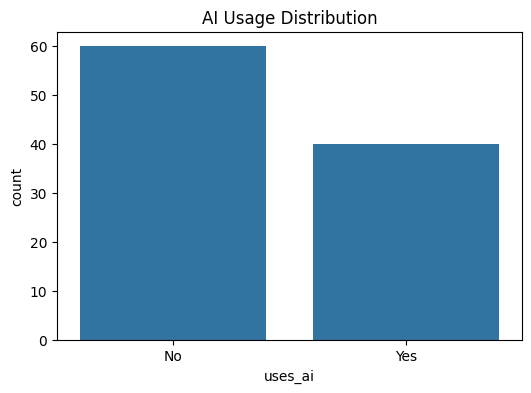

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='uses_ai', data=df)
plt.title("AI Usage Distribution")
plt.show()

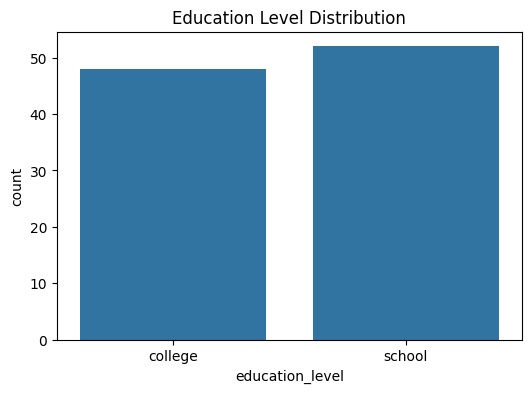

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='education_level', data=df)
plt.title("Education Level Distribution")
plt.show()

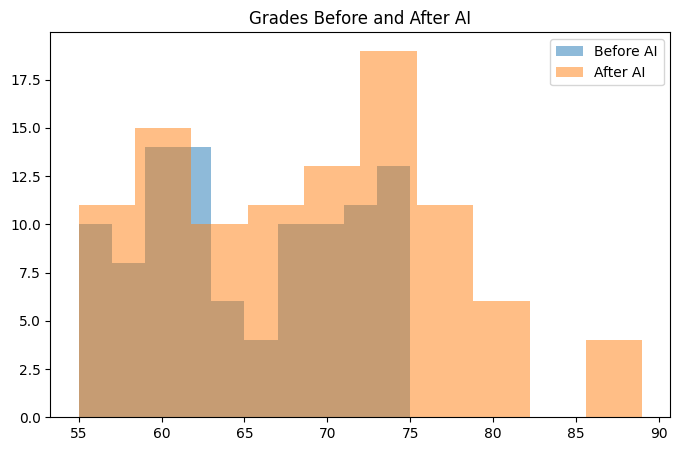

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df['grades_before_ai'],
         alpha=0.5,
         label='Before AI')
plt.hist(df['grades_after_ai'],
         alpha=0.5,
         label='After AI')
plt.legend()
plt.title("Grades Before and After AI")
plt.show()

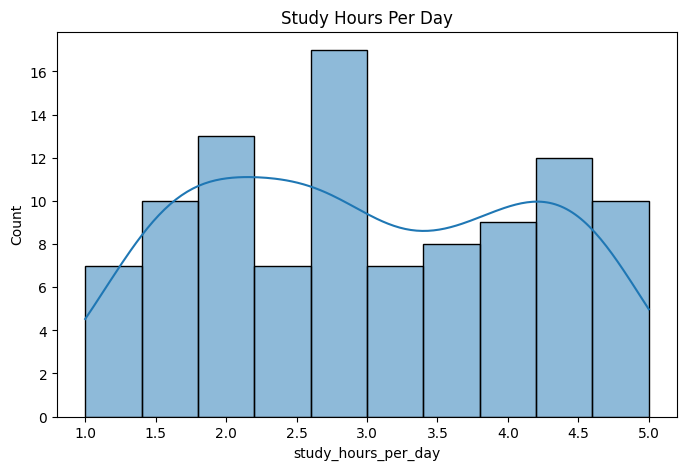

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['study_hours_per_day'],
             bins=10,
             kde=True)
plt.title("Study Hours Per Day")
plt.show()

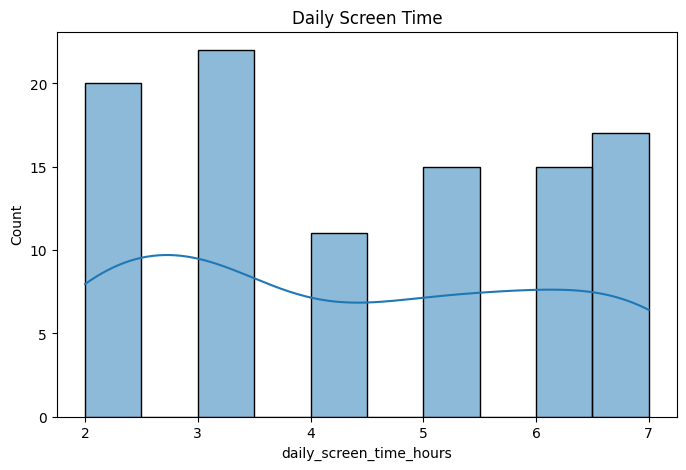

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['daily_screen_time_hours'],
             bins=10,
             kde=True)
plt.title("Daily Screen Time")
plt.show()

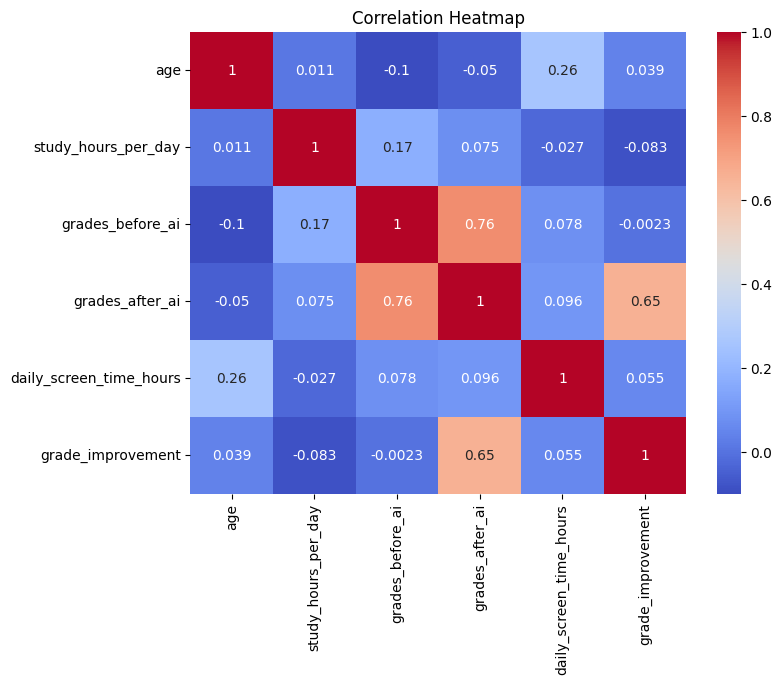

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

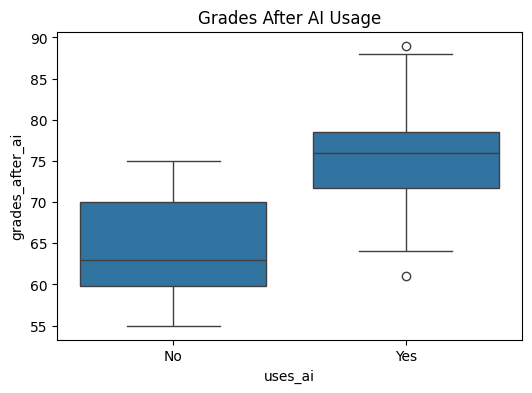

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='uses_ai',
    y='grades_after_ai',
    data=df
)
plt.title("Grades After AI Usage")
plt.show()

# **TASK 5: Predictive Model**

In [29]:
X = df[['age',
        'study_hours_per_day',
        'daily_screen_time_hours',
        'grades_before_ai']]

In [30]:
y = df['grades_after_ai']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred = model.predict(X_test)

In [34]:
print("MAE:",
      mean_absolute_error(y_test, y_pred))
print("MSE:",
      mean_squared_error(y_test, y_pred))
print("R2 Score:",
      r2_score(y_test, y_pred))

MAE: 4.871517173180003
MSE: 28.31820347880455
R2 Score: 0.524443453061765


In [35]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print(results.head(10))

    Actual  Predicted
83      67  71.510645
53      74  78.437877
70      56  60.113289
45      71  76.465142
44      77  77.267823
39      69  73.012108
22      76  67.867190
80      57  60.497119
10      75  79.904137
0       62  67.492424


In [36]:
print("KEY FINDINGS")
print("- Most students are between 14 and 19 years old.")
print("- 40% students use AI tools.")
print("- Average grades increased after AI usage.")
print("- Average screen time is around 4 hours.")
print("- Study hours positively affect grades.")
print("- Linear Regression model predicts grades_after_ai.")

KEY FINDINGS
- Most students are between 14 and 19 years old.
- 40% students use AI tools.
- Average grades increased after AI usage.
- Average screen time is around 4 hours.
- Study hours positively affect grades.
- Linear Regression model predicts grades_after_ai.
